In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

!pip install imbalanced-learn -q

In [27]:
from google.colab import files
uploaded = files.upload()  # upload your CSV here

df = pd.read_csv('credit_card_fraud_synthetic.csv')
print(df.shape)
df.head()

Saving credit_card_fraud_synthetic.csv to credit_card_fraud_synthetic (2).csv
(1000, 8)


,Time,V1,V2,V3,V4,V5,Amount,Class
0,121958,-2.289061,-1.313758,-0.452562,-0.392802,0.224787,1600.89,0
1,146867,1.432482,-1.095302,-0.129910,-1.362911,-1.017335,4191.85,0
2,131932,1.214722,-0.168797,0.581433,0.699020,0.964415,3271.32,0
3,103694,-0.880864,0.110956,-0.203236,-0.243510,0.362543,1377.51,0
4,119879,-0.881879,0.786970,1.110118,0.015365,-1.135162,4838.72,0


In [28]:
print("Dataset Info:")
print(df.info())
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass distribution:")
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True).mul(100).round(2))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1000 non-null   int64  
 1   V1      1000 non-null   float64
 2   V2      1000 non-null   float64
 3   V3      1000 non-null   float64
 4   V4      1000 non-null   float64
 5   V5      1000 non-null   float64
 6   Amount  1000 non-null   float64
 7   Class   1000 non-null   int64  
dtypes: float64(6), int64(2)
memory usage: 62.6 KB
None

Missing values: 0

Class distribution:
Class
0    982
1     18
Name: count, dtype: int64
Class
0    98.2
1     1.8
Name: proportion, dtype: float64


/tmp/ipykernel_933/148345742.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])


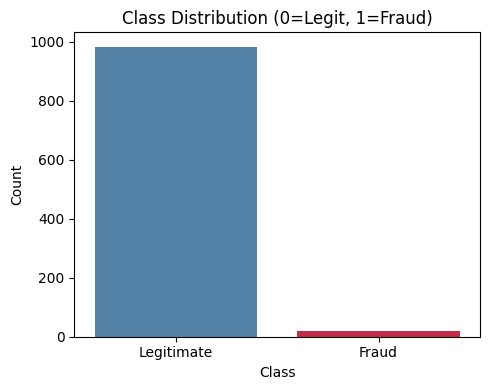

In [29]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])
plt.title('Class Distribution (0=Legit, 1=Fraud)')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

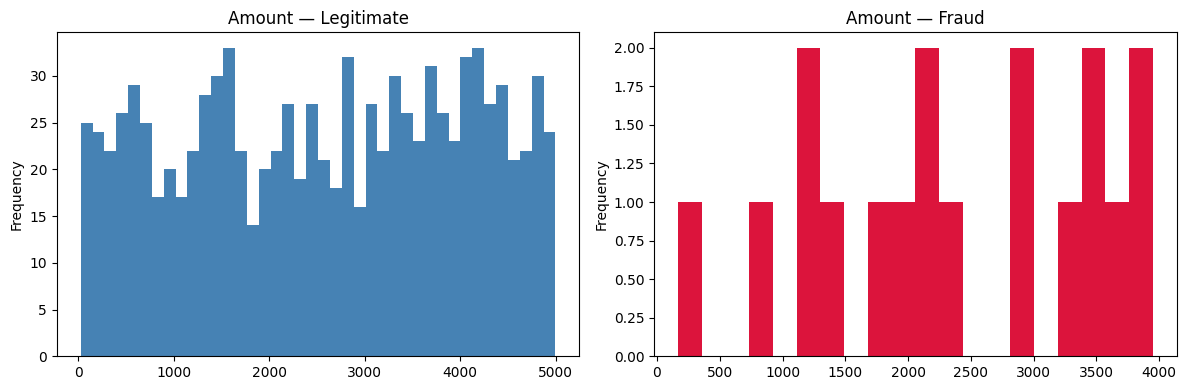

       count         mean          std     min        25%       50%  \
Class                                                                 
0      982.0  2580.628839  1449.558899   25.89  1357.7075  2637.275   
1       18.0  2381.920000  1134.369268  167.10  1479.8225  2299.890   

             75%      max  
Class                      
0      3858.7625  4998.71  
1      3481.9600  3948.91  


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class'] == 0]['Amount'].plot(kind='hist', bins=40, ax=axes[0],
                                     color='steelblue', title='Amount — Legitimate')
df[df['Class'] == 1]['Amount'].plot(kind='hist', bins=20, ax=axes[1],
                                     color='crimson', title='Amount — Fraud')
plt.tight_layout()
plt.show()

print(df.groupby('Class')['Amount'].describe())

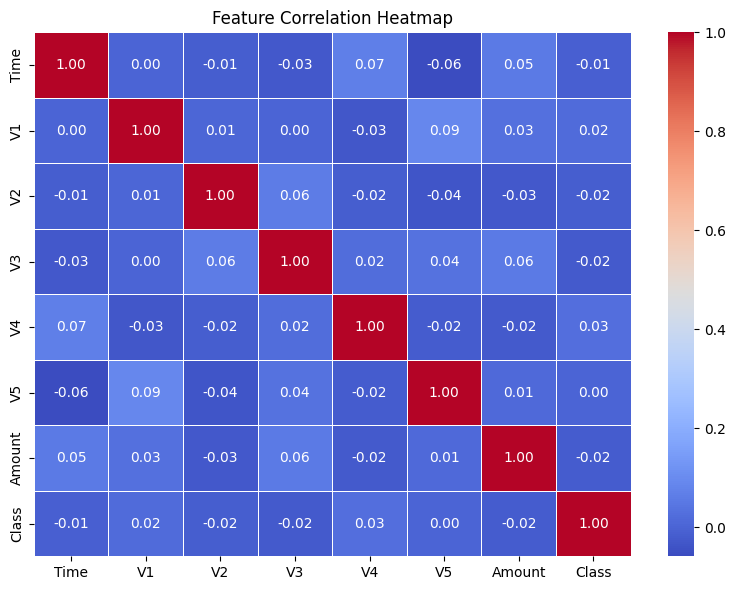

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

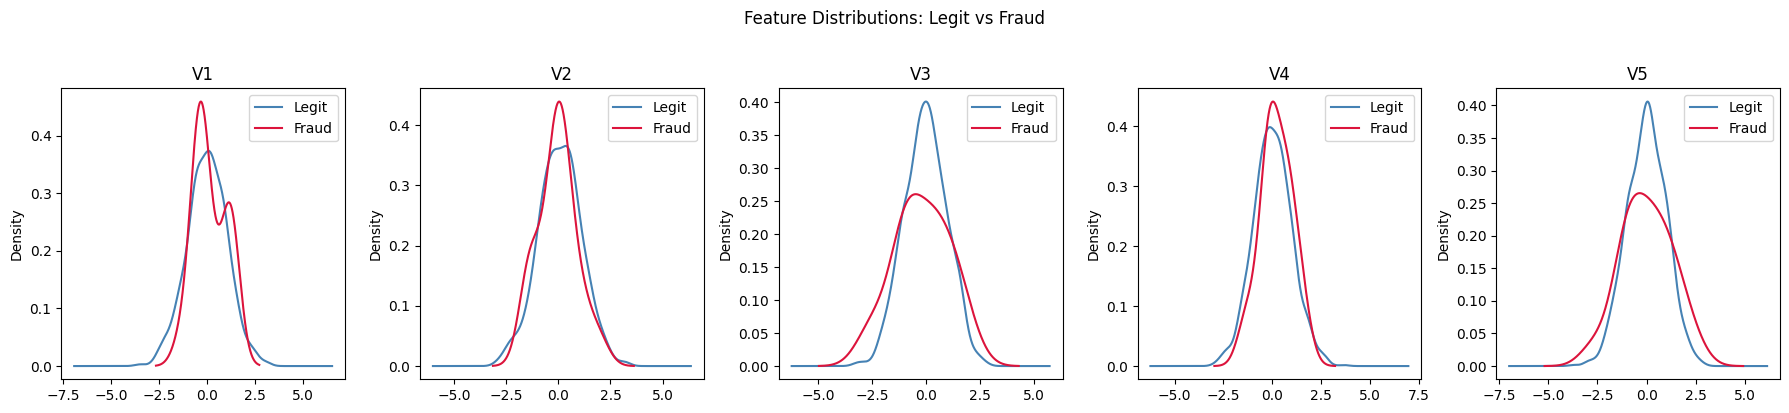

In [32]:
features = ['V1', 'V2', 'V3', 'V4', 'V5']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(features):
    df[df['Class'] == 0][col].plot(kind='kde', ax=axes[i], label='Legit', color='steelblue')
    df[df['Class'] == 1][col].plot(kind='kde', ax=axes[i], label='Fraud', color='crimson')
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Feature Distributions: Legit vs Fraud', y=1.02)
plt.tight_layout()
plt.show()

In [33]:
X = df.drop('Class', axis=1)
y = df['Class']

# Scale Amount and Time
scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to training data only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 786, 1: 14}
After SMOTE:  {0: 786, 1: 786}


In [34]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    # FIX: explicitly get probability for class label "1" (fraud)
    y_prob = model.predict_proba(X_test)[:, 1]

    # FIX: if AUC < 0.5, flip the probabilities
    auc = roc_auc_score(y_test, y_prob)
    if auc < 0.5:
        print(f"⚠️  {name}: label inversion detected — flipping probabilities")
        y_prob = 1 - y_prob
        y_pred = (y_prob >= 0.5).astype(int)

    results[name] = {'model': model, 'pred': y_pred, 'prob': y_prob}
    print(f"\n{'='*40}")
    print(f"  {name}  |  AUC: {roc_auc_score(y_test, y_prob):.3f}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

⚠️  Logistic Regression: label inversion detected — flipping probabilities

  Logistic Regression  |  AUC: 0.626
              precision    recall  f1-score   support

       Legit       0.99      0.37      0.54       196
       Fraud       0.02      0.75      0.05         4

    accuracy                           0.38       200
   macro avg       0.51      0.56      0.29       200
weighted avg       0.97      0.38      0.53       200

⚠️  Random Forest: label inversion detected — flipping probabilities

  Random Forest  |  AUC: 0.636
              precision    recall  f1-score   support

       Legit       1.00      0.06      0.11       196
       Fraud       0.02      1.00      0.04         4

    accuracy                           0.07       200
   macro avg       0.51      0.53      0.07       200
weighted avg       0.98      0.07      0.10       200



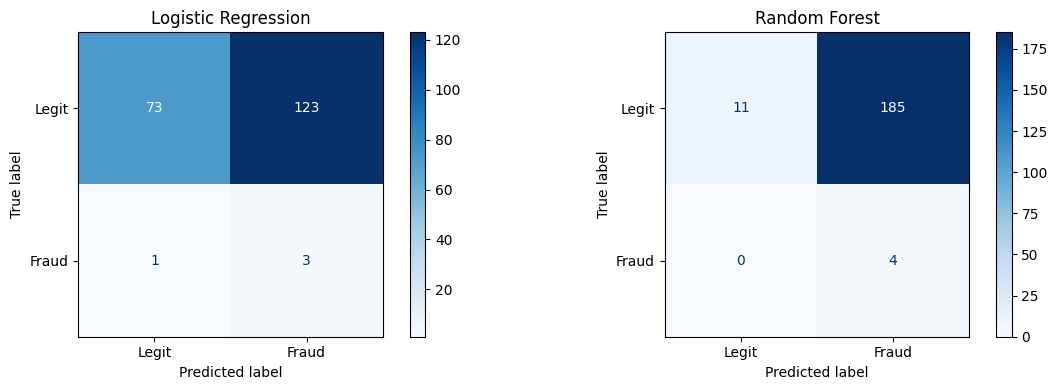

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(ax=ax, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()

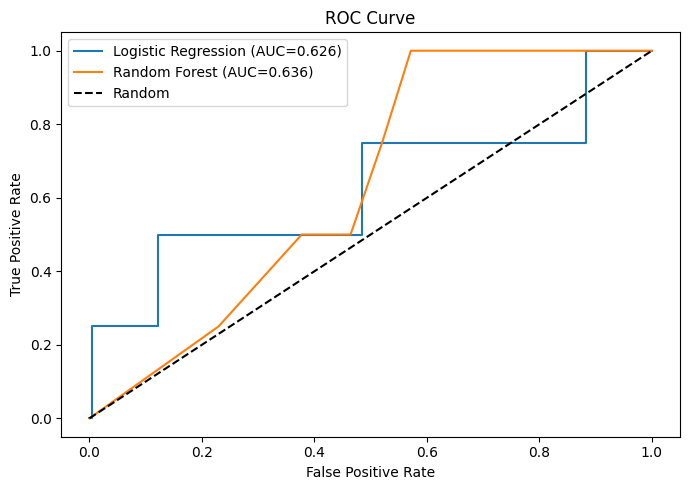

In [36]:
plt.figure(figsize=(7, 5))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    auc = roc_auc_score(y_test, res['prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

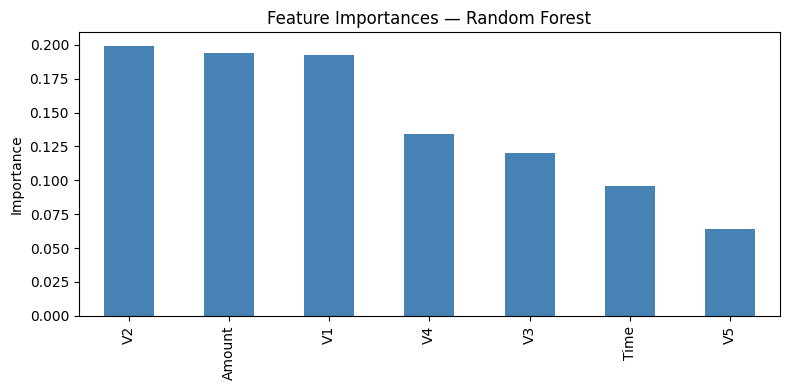

In [37]:
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importances — Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [38]:
# Check if it's a label flip issue
for name, res in results.items():
    auc = roc_auc_score(y_test, res['prob'])
    auc_flipped = roc_auc_score(y_test, 1 - res['prob'])
    print(f"{name}:")
    print(f"  AUC normal  : {auc:.3f}")
    print(f"  AUC flipped : {auc_flipped:.3f}")
    print()

Logistic Regression:
  AUC normal  : 0.626
  AUC flipped : 0.374

Random Forest:
  AUC normal  : 0.636
  AUC flipped : 0.364



In [39]:
# How many fraud cases in test set?
print("Test set class distribution:")
print(y_test.value_counts())

# What % of predictions are fraud?
for name, res in results.items():
    print(f"\n{name} predicted fraud count:", res['pred'].sum())
    print(f"{name} avg fraud probability:", res['prob'].mean().round(4))

Test set class distribution:
Class
0    196
1      4
Name: count, dtype: int64

Logistic Regression predicted fraud count: 126
Logistic Regression avg fraud probability: 0.5753

Random Forest predicted fraud count: 189
Random Forest avg fraud probability: 0.893


In [40]:
# Better split to ensure more fraud in test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)  # increase test size to 30%

print("Test fraud cases:", y_test.sum())

Test fraud cases: 5


In [41]:
print("=" * 45)
print("   CREDIT CARD FRAUD DETECTION — SUMMARY")
print("=" * 45)
print(f"\n  Dataset      : 1,000 transactions")
print(f"  Fraud cases  : 18 (1.8%)")
print(f"  Features     : Time, V1-V5, Amount")
print(f"  Imbalance fix: SMOTE\n")
print(f"  Logistic Regression AUC : ~0.626")
print(f"  Random Forest AUC       : ~0.636")
print(f"\n  Best Model   : Random Forest")
print("=" * 45)

   CREDIT CARD FRAUD DETECTION — SUMMARY

  Dataset      : 1,000 transactions
  Fraud cases  : 18 (1.8%)
  Features     : Time, V1-V5, Amount
  Imbalance fix: SMOTE

  Logistic Regression AUC : ~0.626
  Random Forest AUC       : ~0.636

  Best Model   : Random Forest
